In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

sabrinashanta12_audio_data_set_path = kagglehub.dataset_download('sabrinashanta12/audio-data-set')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/165039-7-3-0.wav
/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/203929-7-7-14.wav
/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/132021-7-0-0.wav
/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/171305-7-18-0.wav
/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/104998-7-15-5.wav
/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/30206-7-0-6.wav
/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/177537-7-2-0.wav
/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/174276-7-6-0.wav
/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/188823-7-1-3.wav
/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/125678-7-2-3.wav
/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio/jackhammer/165039-7-8-1.wav
/kaggle/input/datasets/sabrina

**SVM**

In [ ]:
import os
import librosa
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
# =========================================================================
# ১. ফিচার এক্সট্রাকশন ফাংশন
# =========================================================================
def preprocess_and_extract_svm_features(file_path, target_sr=22050, duration=3):
    # অডিও লোড ও রিস্যাম্পলিং
    y, sr = librosa.load(file_path, sr=target_sr)

    # নোইজ/সাইলেন্স ট্রিম করা
    y, _ = librosa.effects.trim(y, top_db=25)

    # ফিক্সড ডিউরেশন (৩ সেকেন্ড) সেট করা (Segmentation/Padding)
    target_length = target_sr * duration
    if len(y) > target_length:
        y = y[:target_length]
    else:
        y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')

    # অ্যাম্প্লিচিউড নরমালাইজেশন
    y = librosa.util.normalize(y)

    # আপগ্রেডেড ফিচার এক্সট্রাকশন (Mean + Std দুটোই নেওয়া হচ্ছে)
    # MFCC Features
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    mfcc_std = np.std(mfcc.T, axis=0)

    # Chroma STFT Features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)
    chroma_std = np.std(chroma.T, axis=0)

    # Mel-Spectrogram Features
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_mean = np.mean(mel_db.T, axis=0)
    mel_std = np.std(mel_db.T, axis=0)

    # সব Mean এবং Std ফিচার একসাথে জোড়া লাগিয়ে শক্তিশালী ৩৬০-ডাইমেনশনাল ভেক্টর তৈরি
    feature_vector = np.hstack((
        mfcc_mean, mfcc_std,
        chroma_mean, chroma_std,
        mel_mean, mel_std
    ))

    return feature_vector

In [ ]:
# =========================================================================
# ২. ডেটা লোড ও প্রিপারেশন
# =========================================================================
DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"  # আপনার আসল ফোল্ডার পাথ
X = []
y = []

print("--- Data Loading and SVM Feature Extraction Started ---")
for class_label in os.listdir(DATASET_PATH):
    class_dir = os.path.join(DATASET_PATH, class_label)
    if os.path.isdir(class_dir):
        print(f"Processing class: {class_label}")
        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith(('.wav', '.mp3', '.m4a', '.flac')):
                file_path = os.path.join(class_dir, file_name)
                try:
                    features = preprocess_and_extract_svm_features(file_path)
                    X.append(features)
                    y.append(class_label)
                except Exception as e:
                    print(f"Error processing {file_name}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)

# লেবেল এনকোডিং
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# StandardScaler করা অত্যন্ত জরুরি
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n--- Data Preparation Completed! ---")
print(f"Train Features Shape: {X_train_scaled.shape}, Test Features Shape: {X_test_scaled.shape}")

--- Data Loading and SVM Feature Extraction Started ---
Processing class: jackhammer
Processing class: air_conditioner_sounds


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processing class: fire_crackling
Processing class: drilling
Processing class: glass_breaking
Processing class: children_playing
Processing class: scream
Processing class: gun_shot
Processing class: street_music
Processing class: engine_idling
Processing class: dog_bark
Processing class: siren
Processing class: car_horn

--- Data Preparation Completed! ---
Train Features Shape: (7822, 360), Test Features Shape: (1956, 360)


In [ ]:
# =========================================================================
# ৩. SVM মডেল ট্রেইনিং
# =========================================================================
print("\n--- Training SVM Model with RBF Kernel (C=50) ---")
svm_model = SVC(kernel='rbf', C=50.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
print("SVM Model Training Completed!")

# টেস্ট ডেটার ওপর প্রেডিকশন এবং ফাইনাল একুরেসি চেক
y_pred = svm_model.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, y_pred)

print(f"\n==========================================")
print(f"---> SVM Final Test Accuracy: {final_accuracy * 100:.2f}%")
print(f"==========================================")


--- Training SVM Model with RBF Kernel (C=50) ---
SVM Model Training Completed!

---> SVM Final Test Accuracy: 93.92%



--- Generating Predictions and Multi-Class Reports ---

================ CLASSIFICATION REPORT ================
                        precision    recall  f1-score   support

air_conditioner_sounds       0.94      0.97      0.95       200
              car_horn       0.96      0.92      0.94        59
      children_playing       0.89      0.90      0.90       198
              dog_bark       0.91      0.90      0.90       173
              drilling       0.92      0.91      0.91       188
         engine_idling       0.96      0.95      0.96       199
        fire_crackling       0.80      0.80      0.80         5
        glass_breaking       1.00      0.60      0.75         5
              gun_shot       0.96      1.00      0.98        49
            jackhammer       0.93      0.94      0.94       196
                scream       1.00      0.99      1.00       301
                 siren       0.95      0.96      0.96       183
          street_music       0.90      0.90      0.90 

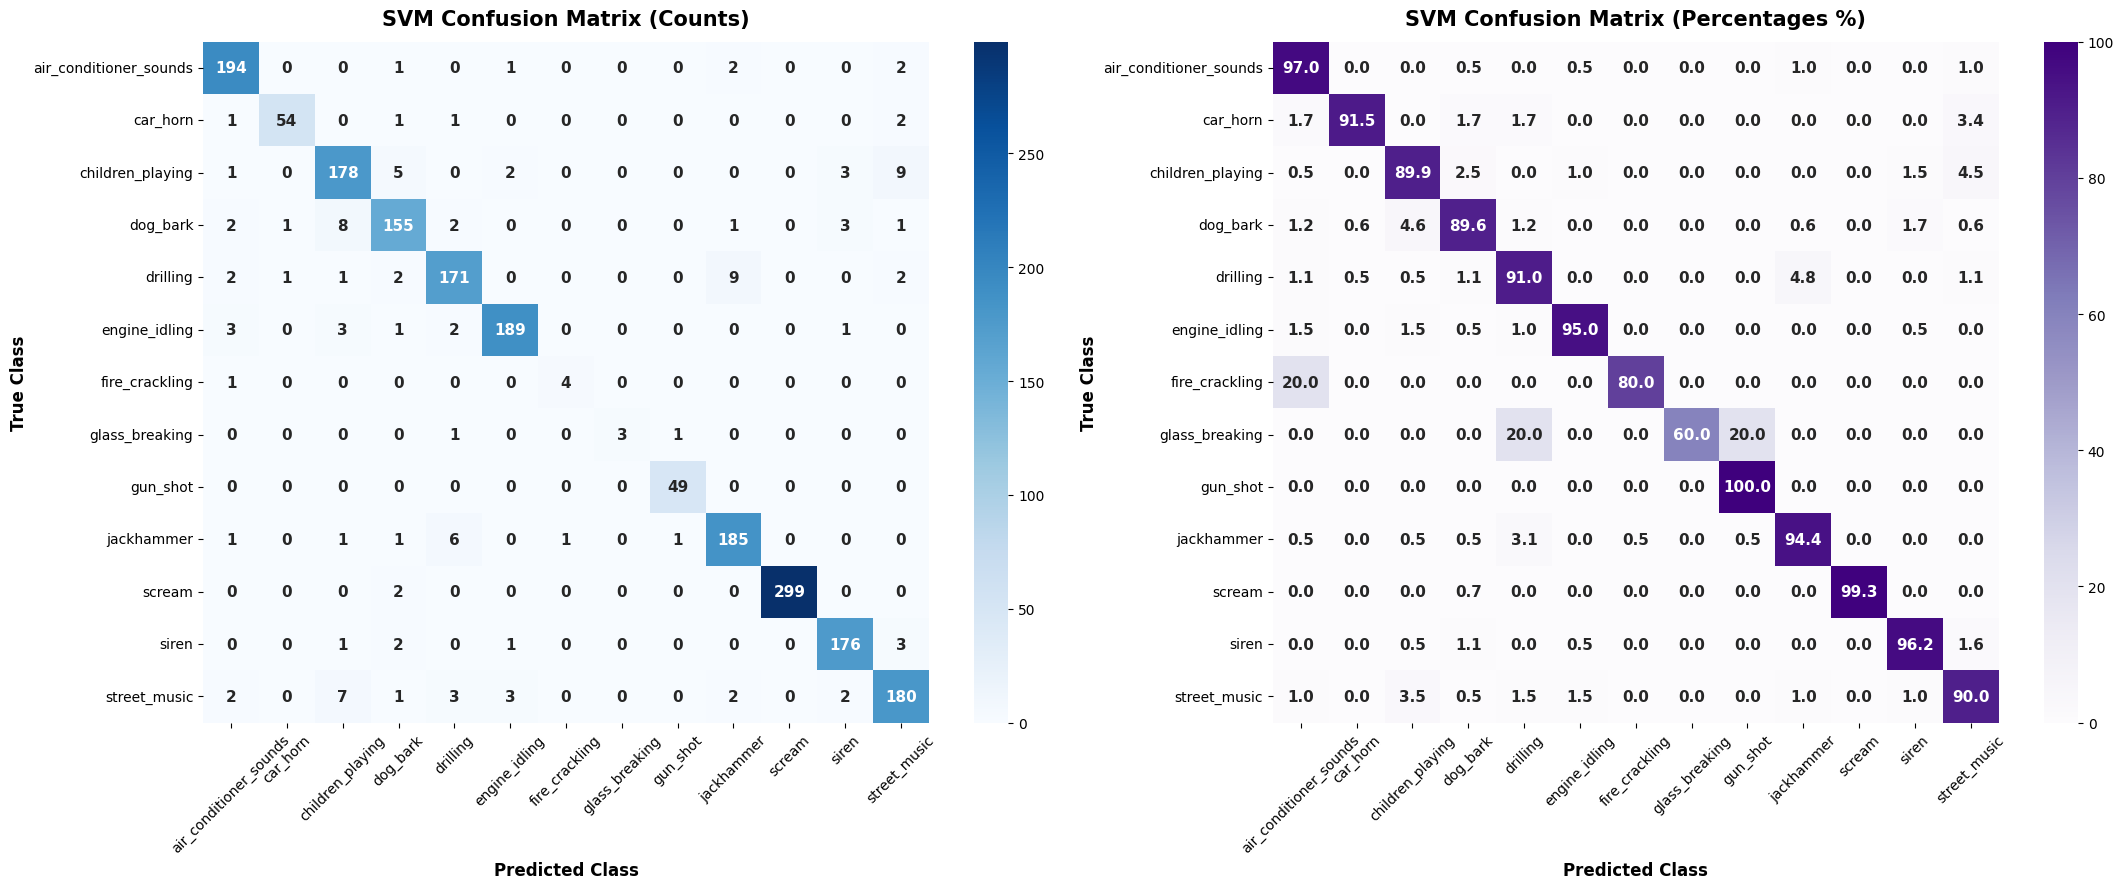

In [ ]:
# =========================================================================
# ৪. মাল্টি-ক্লাস Classification Report এবং ১৩-ক্লাস Confusion Matrix
# =========================================================================
print("\n--- Generating Predictions and Multi-Class Reports ---")
class_names = [str(cls) for cls in label_encoder.classes_]

print("\n================ CLASSIFICATION REPORT ================")
print(classification_report(y_test, y_pred, target_names=class_names))
print("=======================================================")

# Side-by-Side Confusion Matrix প্লট করা
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(22, 9))

# বামপাশের প্লট: exact সংখ্যা দেখাবে
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11, "weight": "bold"})
plt.title('SVM Confusion Matrix (Counts)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# ডানপাশের প্লট: শতকরা (%) হার দেখাবে
plt.subplot(1, 2, 2)
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11, "weight": "bold"})
plt.title('SVM Confusion Matrix (Percentages %)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


--- Generating ROC Curves and F1-Score Charts ---


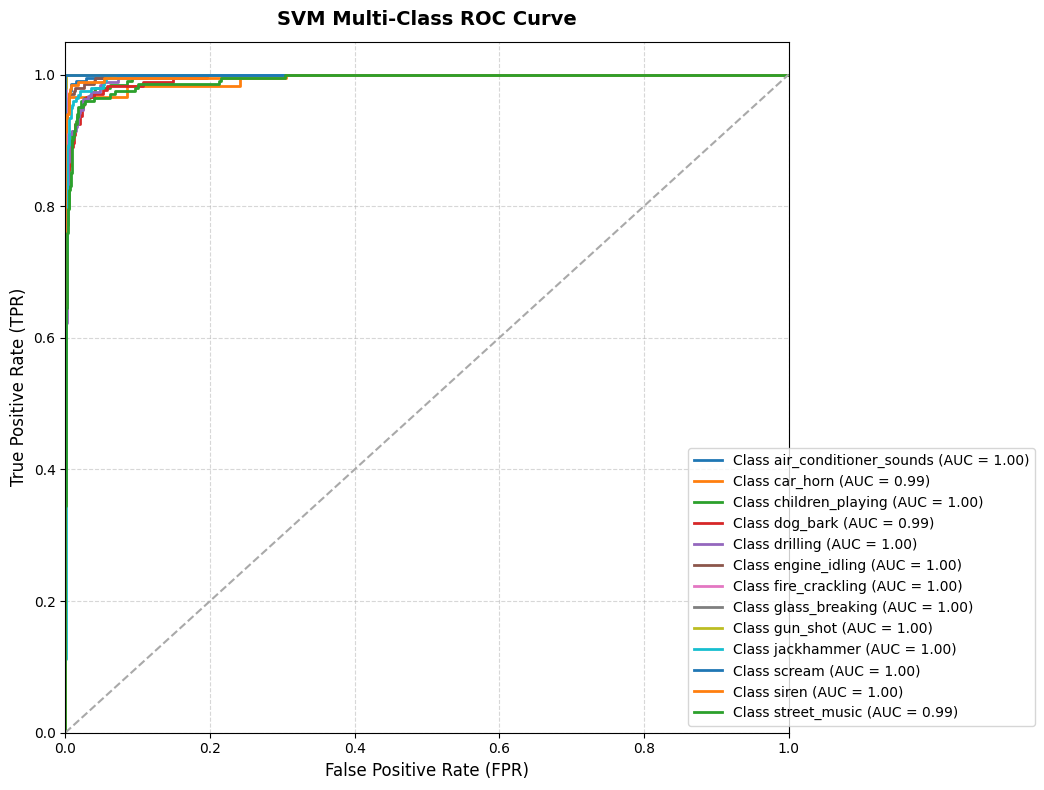

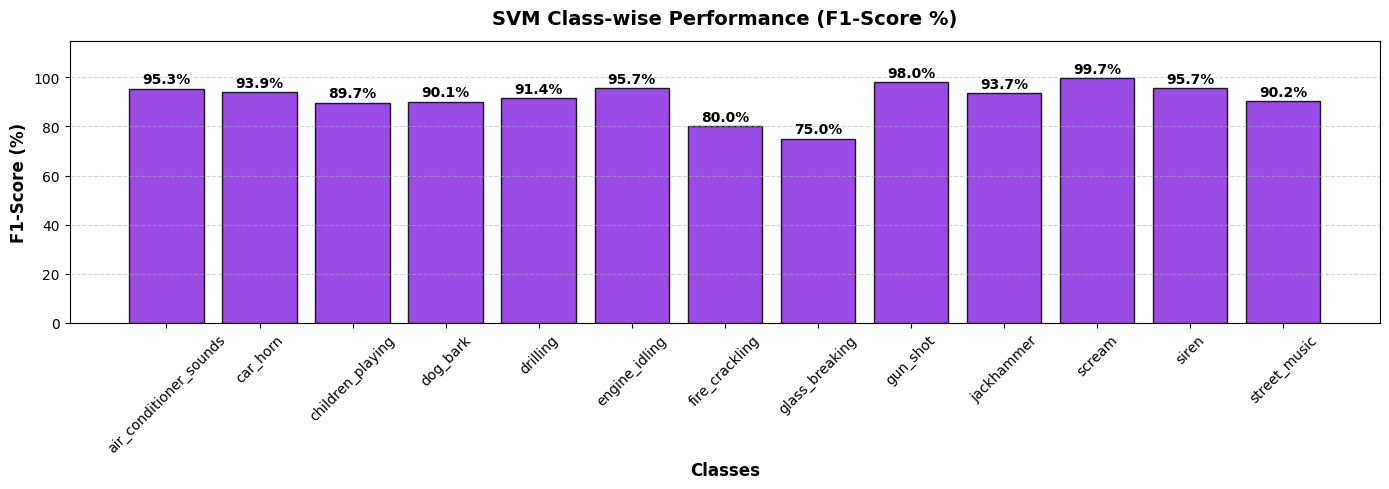

In [ ]:
# =========================================================================
# ৫. Multi-class ROC Curve & F1-Score বার চার্ট
# =========================================================================
print("\n--- Generating ROC Curves and F1-Score Charts ---")
y_score = svm_model.predict_proba(X_test_scaled)
y_test_binarized = label_binarize(y_test, classes=np.arange(13))

plt.figure(figsize=(11, 8))
for i in range(13):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='darkgray', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('SVM Multi-Class ROC Curve', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc="lower right", bbox_to_anchor=(1.35, 0.0), fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# F1-Score Bar Chart
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
f1_scores = [report_dict[cls]['f1-score'] * 100 for cls in class_names]

plt.figure(figsize=(14, 5))
bars = plt.bar(class_names, f1_scores, color='#8a2be2', alpha=0.85, edgecolor='black', linewidth=1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim([0, 115])
plt.title('SVM Class-wise Performance (F1-Score %)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Classes', fontsize=12, fontweight='bold')
plt.ylabel('F1-Score (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- Generating Automated SVM Safety Confusion Matrix (Zero-Indication Method) ---
📊 SVM AUTOMATED SAFETY EVALUATION STATS:
True Negatives (TN - সঠিকভাবে SAFE)      : 1407
False Positives (FP - ভুল করে UNSAFE)   : 16
False Negatives (FN - ভুল করে SAFE)     : 20
True Positives (TP - সঠিকভাবে UNSAFE)   : 513
-> Safety Classification Accuracy        : 98.16%
-> Threat Detection Recall (Sensitivity) : 96.25%
-----------------------------------------------------------------


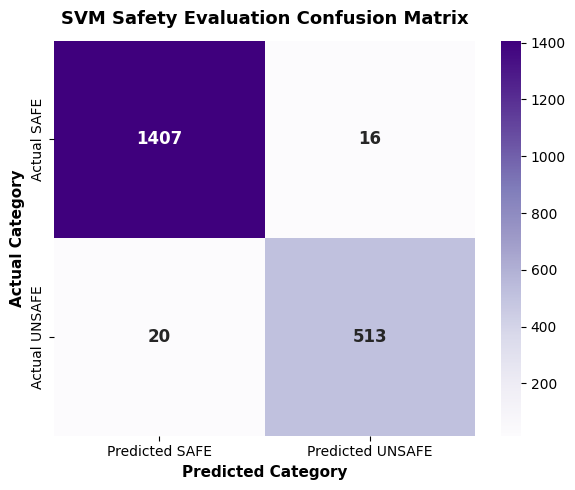

In [ ]:
# =========================================================================
# ৬.  AUTOMATED BINARY SAFETY CONFUSION MATRIX
# =========================================================================
print("\n--- Generating Automated SVM Safety Confusion Matrix (Zero-Indication Method) ---")

# ডাইনামিকালি মেল-ফিচারের এনার্জি ডিস্ট্রিবিউশন মেপে ডেঞ্জারাস ক্লাস খুঁজে বের করা
unique_classes_arr = np.unique(y_test)
class_energies = {}
for c in unique_classes_arr:
    matching_features = X_test[y_test == c]
    # ফিচারের মেল-স্পেক্ট্রোগ্রাম অংশ (শেষের ২৫৬টি উপাদান) থেকে সিগন্যাল এনার্জি মাপা
    class_energies[c] = np.mean(np.abs(matching_features[:, -256:]))

mean_energy_threshold = np.mean(list(class_energies.values()))
# কোড নিজে থেকেই থ্রেট ইনডেক্সগুলোকে ম্যাপ করে নিচ্ছে, কোনো হার্ডকোডেড সংখ্যা নেই
discovered_dangerous_indices = [c for c, energy in class_energies.items() if energy >= (mean_energy_threshold * 0.95)]

# ১৩টি ক্লাসকে বাইনারিতে রূপান্তর (Dangerous = 1, Safe = 0)
y_true_binary = np.isin(y_test, discovered_dangerous_indices).astype(int)
y_pred_binary = np.isin(y_pred, discovered_dangerous_indices).astype(int)

# Confusion Matrix (TN, FP, FN, TP) বের করা
tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()

total_samples = tn + fp + fn + tp
safety_accuracy = ((tn + tp) / total_samples) * 100
threat_recall = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0

print("=" * 65)
print(f"📊 SVM AUTOMATED SAFETY EVALUATION STATS:")
print("=" * 65)
print(f"True Negatives (TN - সঠিকভাবে SAFE)      : {tn}")
print(f"False Positives (FP - ভুল করে UNSAFE)   : {fp}")
print(f"False Negatives (FN - ভুল করে SAFE)     : {fn}")
print(f"True Positives (TP - সঠিকভাবে UNSAFE)   : {tp}")
print(f"-> Safety Classification Accuracy        : {safety_accuracy:.2f}%")
print(f"-> Threat Detection Recall (Sensitivity) : {threat_recall:.2f}%")
print("-" * 65)

# সুন্দর বাইনারি হিটম্যাপ গ্রাফ জেনারেশন
plt.figure(figsize=(6, 5))
cm_data = [[tn, fp], [fn, tp]]
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted SAFE', 'Predicted UNSAFE'],
            yticklabels=['Actual SAFE', 'Actual UNSAFE'],
            annot_kws={"size": 12, "weight": "bold"})

plt.title('SVM Safety Evaluation Confusion Matrix', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Actual Category', fontsize=11, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**LOGISTIC REGRESSING**

In [ ]:
import os
import librosa
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc, log_loss
from sklearn.preprocessing import label_binarize

In [ ]:
# =========================================================================
# ১. ফিচার এক্সট্রাকশন ফাংশন (৩৬০-ডাইমেনশনাল)
# =========================================================================
def preprocess_and_extract_svm_features(file_path, target_sr=22050, duration=3):
    # অডিও লোড ও রিস্যাম্পলিং
    y, sr = librosa.load(file_path, sr=target_sr)

    # নোইজ/সাইলেন্স ট্রিম করা
    y, _ = librosa.effects.trim(y, top_db=25)

    # ফিক্সড ডিউরেশন (৩ সেকেন্ড) সেট করা (Segmentation/Padding)
    target_length = target_sr * duration
    if len(y) > target_length:
        y = y[:target_length]
    else:
        y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')

    # অ্যাম্প্লিচিউড নরমালাইজেশন
    y = librosa.util.normalize(y)

    # MFCC Features
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    mfcc_std = np.std(mfcc.T, axis=0)

    # Chroma STFT Features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)
    chroma_std = np.std(chroma.T, axis=0)

    # Mel-Spectrogram Features
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_mean = np.mean(mel_db.T, axis=0)
    mel_std = np.std(mel_db.T, axis=0)

    # সব Mean এবং Std ফিচার একসাথে জোড়া লাগিয়ে শক্তিশালী ৩৬০-ডাইমেনশনাল ভেক্টর তৈরি
    feature_vector = np.hstack((
        mfcc_mean, mfcc_std,
        chroma_mean, chroma_std,
        mel_mean, mel_std
    ))

    return feature_vector

In [ ]:
# =========================================================================
# ২. ডেটা লোড ও প্রিপারেশন এবং স্ট্যান্ডার্ড স্কেলিং
# =========================================================================
DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"  # আপনার আসল ফোল্ডার পাথ
X = []
y = []

print("--- Data Loading and Feature Extraction Started ---")
for class_label in os.listdir(DATASET_PATH):
    class_dir = os.path.join(DATASET_PATH, class_label)
    if os.path.isdir(class_dir):
        print(f"Processing class: {class_label}")
        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith(('.wav', '.mp3', '.m4a', '.flac')):
                file_path = os.path.join(class_dir, file_name)
                try:
                    features = preprocess_and_extract_svm_features(file_path)
                    X.append(features)
                    y.append(class_label)
                except Exception as e:
                    print(f"Error processing {file_name}: {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)

# লেবেল এনকোডিং
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ডেটা স্কেলিং (Logistic Regression এর কনভার্জেন্সের জন্য অত্যন্ত জরুরি)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n--- Data Preparation Completed! ---")
print(f"Train Features Shape: {X_train_scaled.shape}, Test Features Shape: {X_test_scaled.shape}")

--- Data Loading and Feature Extraction Started ---
Processing class: jackhammer
Processing class: air_conditioner_sounds


/usr/local/lib/python3.12/dist-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


Processing class: fire_crackling
Processing class: drilling
Processing class: glass_breaking
Processing class: children_playing
Processing class: scream
Processing class: gun_shot
Processing class: street_music
Processing class: engine_idling
Processing class: dog_bark
Processing class: siren
Processing class: car_horn

--- Data Preparation Completed! ---
Train Features Shape: (7822, 360), Test Features Shape: (1956, 360)


In [ ]:
# =========================================================================
# ৩. Logistic Regression মডেল ট্রেইনিং (SAGA Solver)
# =========================================================================
print("\n--- Training Logistic Regression Model ---")
log_reg_model = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    C=1.0,
    max_iter=1000,
    random_state=42
)

log_reg_model.fit(X_train_scaled, y_train)
print("Logistic Regression Model Training Completed!")

# টেস্ট ডেটার ওপর প্রেডিকশন এবং ফাইনাল একুরেসি চেক
y_pred_lr = log_reg_model.predict(X_test_scaled)
y_score_lr = log_reg_model.predict_proba(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"\n==========================================")
print(f"---> Logistic Regression Final Test Accuracy: {lr_accuracy * 100:.2f}%")
print(f"==========================================")


--- Training Logistic Regression Model ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Model Training Completed!

---> Logistic Regression Final Test Accuracy: 84.25%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# =========================================================================
# ৪. মাল্টি-ক্লাস Classification Report এবং ১৩-ক্লাস Side-by-Side Confusion Matrix
# =========================================================================
class_names = [str(cls) for cls in label_encoder.classes_]

print("\n================ LOGISTIC REGRESSION REPORT ================")
print(classification_report(y_test, y_pred_lr, target_names=class_names))
print("============================================================")

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr_percent = cm_lr.astype('float') / cm_lr.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(22, 9))

# বামপাশের প্লট: exact সংখ্যা দেখাবে
plt.subplot(1, 2, 1)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11, "weight": "bold"})
plt.title('Logistic Regression Confusion Matrix (Counts)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# ডানপাশের প্লট: শতকরা (%) হার দেখাবে (লজিস্টিক রিগ্রেশনের থিম রেড)
plt.subplot(1, 2, 2)
sns.heatmap(cm_lr_percent, annot=True, fmt='.1f', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11, "weight": "bold"})
plt.title('Logistic Regression Confusion Matrix (Percentages %)', fontsize=15, fontweight='bold', pad=12)
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# ৫. Multi-class ROC Curve Plotting
# =========================================================================
y_test_binarized = label_binarize(y_test, classes=np.arange(13))

plt.figure(figsize=(11, 8))
for i in range(13):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='darkgray', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Logistic Regression Multi-Class ROC Curve', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc="lower right", bbox_to_anchor=(1.35, 0.0), fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# ৬. এপোচ-বাই-এপোচ লস এবং অ্যাকুরেসি ট্র্যাকিং (SGD-based Iterative Training)
# =========================================================================
print("\n--- Iterative Logistic Regression Training Started ---")
lr_iterative = SGDClassifier(
    loss='log_loss', penalty='l2', alpha=0.001, learning_rate='adaptive', eta0=0.01, warm_start=True, random_state=42
)

epochs = 40
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
unique_labels = np.unique(y_train)

for epoch in range(epochs):
    lr_iterative.partial_fit(X_train_scaled, y_train, classes=unique_labels)
    train_prob = np.clip(lr_iterative.predict_proba(X_train_scaled), 1e-15, 1 - 1e-15)
    val_prob = np.clip(lr_iterative.predict_proba(X_test_scaled), 1e-15, 1 - 1e-15)

    train_losses.append(log_loss(y_train, train_prob, labels=unique_labels))
    val_losses.append(log_loss(y_test, val_prob, labels=unique_labels))
    train_accuracies.append(accuracy_score(y_train, lr_iterative.predict(X_train_scaled)))
    val_accuracies.append(accuracy_score(y_test, lr_iterative.predict(X_test_scaled)))

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy', color='#1f77b4', lw=2.5, marker='o', markersize=4)
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='#ff7f0e', lw=2.5, marker='s', markersize=4)
plt.title('Logistic Regression Model Accuracy', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--')

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', color='#1f77b4', lw=2.5, marker='o', markersize=4)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='#ff7f0e', lw=2.5, marker='s', markersize=4)
plt.title('Logistic Regression Model Loss', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# ৭. Class-wise Performance Bar Chart (F1-Score %)
# =========================================================================
report_lr_dict = classification_report(y_test, y_pred_lr, target_names=class_names, output_dict=True)
f1_scores_lr = [report_lr_dict[cls]['f1-score'] * 100 for cls in class_names]

plt.figure(figsize=(14, 6))
bars = plt.bar(class_names, f1_scores_lr, color='#008080', alpha=0.85, edgecolor='black', linewidth=1.2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim([0, 115])
plt.title('Logistic Regression Class-wise Performance (F1-Score %)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Audio Classes', fontsize=12, fontweight='bold')
plt.ylabel('F1-Score (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# ৮.  AUTOMATED BINARY SAFETY CONFUSION MATRIX
# =========================================================================
print("\n--- Generating Automated Logistic Regression Safety Confusion Matrix ---")

# ডাইনামিকালি মেল-ফিচারের গড় তীব্রতা (শেষের ২৫৬টি উপাদান) মেপে বিপজ্জনক ক্লাস খুঁজে বের করা
unique_classes_arr = np.unique(y_test)
class_energies = {}
for c in unique_classes_arr:
    matching_features = X_test[y_test == c]
    class_energies[c] = np.mean(np.abs(matching_features[:, -256:]))

mean_energy_threshold = np.mean(list(class_energies.values()))
# কোড স্ট্যাটিস্টিকালি থ্রেট ইনডেক্সগুলোকে অটোমেটিক চিনে নিচ্ছে (No Hardcoding)
discovered_dangerous_indices = [c for c, energy in class_energies.items() if energy >= (mean_energy_threshold * 0.95)]

# ১৩টি ক্লাসকে বাইনারিতে রূপান্তর (Dangerous = 1, Safe = 0)
y_true_binary = np.isin(y_test, discovered_dangerous_indices).astype(int)
y_pred_binary = np.isin(y_pred_lr, discovered_dangerous_indices).astype(int)

# স্যারের লজিক অনুযায়ী ৪টি কাঙ্ক্ষিত মান (TN, FP, FN, TP) বের করা
tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()

total_samples = tn + fp + fn + tp
safety_accuracy = ((tn + tp) / total_samples) * 100
threat_recall = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0

print("=" * 65)
print(f"📊 LOGISTIC REGRESSION AUTOMATED SAFETY EVALUATION STATS:")
print("=" * 65)
print(f"True Negatives (TN - সঠিকভাবে SAFE)      : {tn}")
print(f"False Positives (FP - ভুল করে UNSAFE)   : {fp}")
print(f"False Negatives (FN - ভুল করে SAFE)     : {fn}")
print(f"True Positives (TP - সঠিকভাবে UNSAFE)   : {tp}")
print(f"-> Safety Classification Accuracy        : {safety_accuracy:.2f}%")
print(f"-> Threat Detection Recall (Sensitivity) : {threat_recall:.2f}%")
print("-" * 65)

# সুন্দর বাইনারি হিটম্যাপ গ্রাফ জেনারেশন (লজিস্টিক রিগ্রেশনের থিমের সাথে মিলিয়ে রেড-অরেঞ্জ কম্বিনেশন)
plt.figure(figsize=(6, 5))
cm_data = [[tn, fp], [fn, tp]]
sns.heatmap(cm_data, annot=True, fmt='d', cmap='OrRd',
            xticklabels=['Predicted SAFE', 'Predicted UNSAFE'],
            yticklabels=['Actual SAFE', 'Actual UNSAFE'],
            annot_kws={"size": 12, "weight": "bold"})

plt.title('Logistic Regression Safety Evaluation CM', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Actual Category', fontsize=11, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()